# Packages & Global Info

In [1]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

agg_levels = np.array([h for _, h in levels.items()])

# Baseline

In [3]:
# baseline data
baseline_df = pd.read_csv('/home/ma/t/tr725/MSc-Project/04_code/combined/combined.csv', index_col=0)

baseline_results = {}
for col in baseline_df.columns:
    baseline_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in baseline_df[col].items()
    }

# Number of Authentications

In [4]:
# n_auth data
n_auth_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/drop_analysis/drop_nauth/drop_nauth_combined.csv", index_col=0)

n_auth_results = {}
for col in n_auth_df.columns:
    n_auth_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_auth_df[col].items()
    }

# Failure Ratio

In [5]:
# failrate data
failrate_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/drop_analysis/drop_failrate/drop_failrate_combined.csv", index_col=0)

failrate_results = {}
for col in failrate_df.columns:
    failrate_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in failrate_df[col].items()
    }

# Number of Distinct Source Computers

In [6]:
# n_src_comps data
n_src_comps_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/drop_analysis/drop_src_comps/drop_src_comps_combined.csv", index_col=0)

n_src_comps_results = {}
for col in n_src_comps_df.columns:
    n_src_comps_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_src_comps_df[col].items()
    }

# Number of Distinct Destination Computers

In [7]:
# n_dest_comps data
n_dest_comps_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/drop_analysis/drop_dest_comps/drop_dest_comps_combined.csv", index_col=0)

n_dest_comps_results = {}
for col in n_dest_comps_df.columns:
    n_dest_comps_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in n_dest_comps_df[col].items()
    }

# Time

In [8]:
# time data
time_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/drop_analysis/drop_time/drop_time_combined.csv", index_col=0)

time_results = {}
for col in time_df.columns:
    time_results[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in time_df[col].items()
    }

# Drop Analysis 

In [9]:
# Dropped features results
dropped_features = {
    'n_auth': n_auth_results,
    'fail_rate': failrate_results,
    'n_src_comps': n_src_comps_results,
    'n_dest_comps': n_dest_comps_results,
    'time': time_results,
}

# Colour scheme
colors = {
    'n_auth': '#4C72B0',       # blue
    'fail_rate': '#DD8452',    # orange
    'n_src_comps': '#55A868',  # green
    'n_dest_comps': '#C44E52', # red
    'time': '#8172B2',         # purple
}


## Plot of means

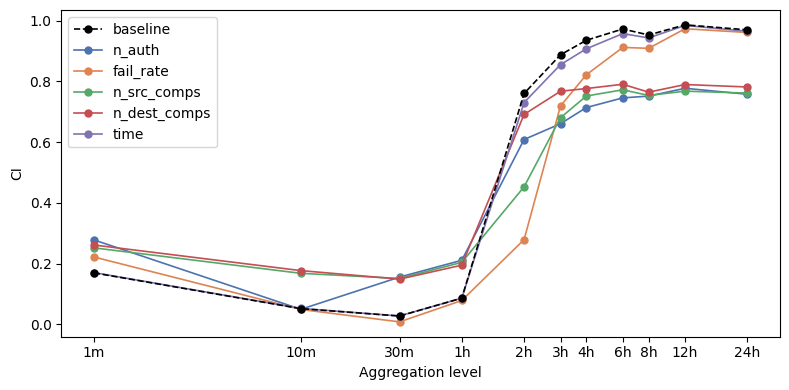

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

# Baseline 
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_means = np.array([v.mean() for v in baseline_vals])
ax.plot(agg_levels, baseline_means, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    means = np.array([v.mean() for v in vals])
    ax.plot(agg_levels, means, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('CI')
ax.legend(loc='upper left')
plt.tight_layout()

## Plot of IQR

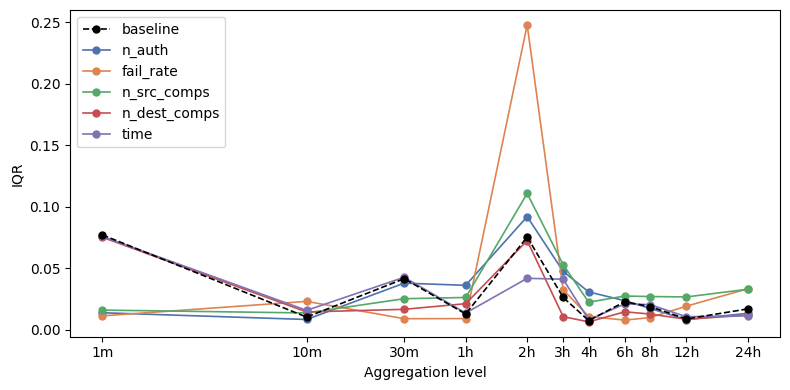

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

# Interquartile range function
def iqr(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    return q3 - q1

# Baseline
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_iqr = np.array([iqr(v) for v in baseline_vals])
ax.plot(agg_levels, baseline_iqr, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    iqrs = np.array([iqr(v) for v in vals])
    ax.plot(agg_levels, iqrs, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('IQR')
ax.legend(loc='upper left')
plt.tight_layout()

# Plot of Medians

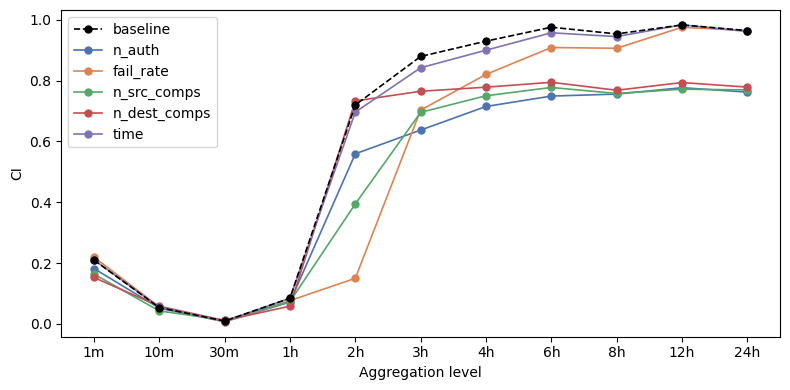

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

# Baseline 
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_medians = np.array([np.median(v) for v in baseline_vals])
ax.plot(np.arange(len(levels)), baseline_medians, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    medians = np.array([np.median(v) for v in vals])
    ax.plot(np.arange(len(levels)), medians, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

# Format x-axis with equal spacing
labels = ['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h']
ax.set_xticks(np.arange(len(levels)))
ax.set_xticklabels(labels)

ax.set_xlabel('Aggregation level')
ax.set_ylabel('CI')
ax.legend(loc='upper left')
plt.tight_layout()

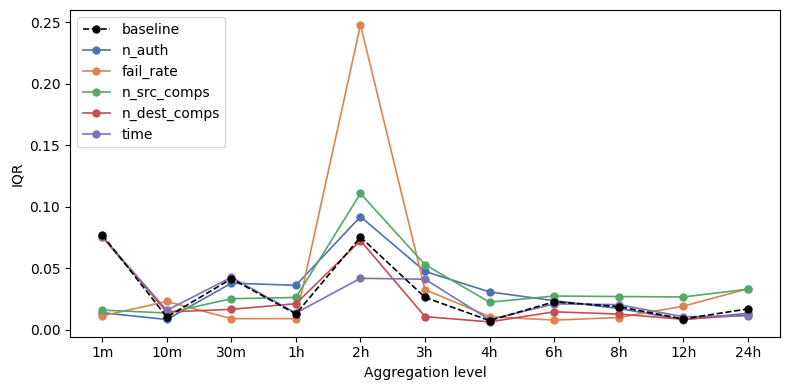

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

# Interquartile range function
def iqr(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    return q3 - q1

# Baseline
baseline_vals = [np.array(list(baseline_results[col].values())) for col in levels]
baseline_iqr = np.array([iqr(v) for v in baseline_vals])
ax.plot(np.arange(len(levels)), baseline_iqr, marker='o', ms=5, lw=1.2, ls='--',
         color='black', zorder=2, label='baseline')

# Dropped features
for name, results in dropped_features.items():
    vals = [np.array(list(results[col].values())) for col in levels]
    iqrs = np.array([iqr(v) for v in vals])
    ax.plot(np.arange(len(levels)), iqrs, marker='o', ms=5, lw=1.2, zorder=1,
             label=name, color=colors[name])

ax.set_xticks(np.arange(len(levels)))
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('IQR')
ax.legend(loc='upper left')
plt.tight_layout()